# Exercice 2 - Bayes risk with absolute loss

## Contexte

Nous savons que pour la **perte quadratique** $l^2(y,z) = (y-z)^2$, le prédicteur de Bayes est :

$$
f^*_{l^2}(x) = \mathbb{E}[Y|X = x]
$$

L'objectif de cet exercice est de déterminer le prédicteur de Bayes pour la **perte absolue** :

$$
l_{\text{absolute}}(y,z) = |y - z|
$$

Et de montrer que $f^*_{l_{\text{absolute}}}(x) \neq f^*_{l^2}(x)$ dans certains cas.

## Question 0 (M)

Proposer une fonction de $\mathbb{R}$ vers $\mathbb{R}$ qui a une dérivée nulle en un point $x_0$, mais où $f(x_0)$ n'est pas un extremum local.

**Fonction proposée** :
$$
f(x) = x^3
$$

**Point considéré** :
$$
x_0 = 0
$$

**Vérification** :
- $f'(x) = 3x^2$
- $f'(0) = 0$ ✓ (dérivée nulle en $x_0 = 0$)
- $f''(x) = 6x$
- $f''(0) = 0$ (test de la dérivée seconde non concluant)

**Analyse du comportement local** :
- Pour $x < 0$ : $f(x) = x^3 < 0$
- Pour $x > 0$ : $f(x) = x^3 > 0$
- $f(0) = 0$

La fonction $f(x) = x^3$ est strictement croissante sur $\mathbb{R}$, donc $f(0) = 0$ n'est ni un maximum ni un minimum local, mais un **point d'inflexion**.

**Justification** : Cette fonction illustre qu'une dérivée nulle ne suffit pas à caractériser un extremum. C'est important pour la question 2 où nous devrons analyser l'optimisation de $\mathbb{E}[|Y - z| \mid X = x]$.

## Question 1 (M + C) - Exemple concret

### Choix du cadre d'étude

**Contexte** : Prédiction du temps de trajet domicile-travail en fonction de l'heure de départ.

**Espaces** :
- $\mathcal{X} = [6, 10]$ (heure de départ, de 6h à 10h)
- $\mathcal{Y} = \mathbb{R}^+$ (temps de trajet en minutes)

**Distribution choisie** :
Pour une heure de départ $x$ donnée, le temps de trajet suit un **mélange bimodal** :

$$
Y|X = x \sim p(x) \cdot \mathcal{N}(\mu_1, \sigma_1^2) + (1-p(x)) \cdot \mathcal{N}(\mu_2, \sigma_2^2)
$$

avec :
- $\mu_1 = 15$ min, $\sigma_1 = 3$ min (trajet rapide : départ tôt ou télétravail)
- $\mu_2 = 45$ min, $\sigma_2 = 5$ min (trajet lent : embouteillages)
- $p(x) = 0{,}7 - 0{,}15\,(x - 6)$ : proportion de trajets rapides, décroissante avec l'heure

**Propriétés** :
1. Espérance conditionnelle (prédicteur L2 optimal) :
$$
\mathbb{E}[Y|X=x] = p(x)\,\mu_1 + (1-p(x))\,\mu_2 = 45 - 30\,p(x)
$$

2. Médiane conditionnelle $m(x)$ : valeur telle que $P(Y \leq m(x) \mid X=x) = 0{,}5$

$$
p(x)\,\Phi\!\left(\frac{m(x)-15}{3}\right) + (1-p(x))\,\Phi\!\left(\frac{m(x)-45}{5}\right) = 0{,}5
$$

**Justification de l'asymétrie** : La distribution est **bimodale** — un groupe part tôt (trajet ~15 min), l'autre part aux heures de pointe (trajet ~45 min). La proportion $p(x)$ décroît avec l'heure, donc la médiane peut changer de mode selon $x$, créant un **écart significatif entre moyenne et médiane**.

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import brentq
import warnings
warnings.filterwarnings('ignore')

In [10]:
# Paramètres du mélange bimodal (temps de trajet domicile-travail)
MU1, SIGMA1 = 15, 3    # Trajet rapide
MU2, SIGMA2 = 45, 5    # Trajet lent (embouteillages)

def p_fast(x):
    """Proportion de trajets rapides à l'heure x"""
    return np.clip(0.7 - 0.15 * (x - 6), 0.05, 0.95)

def generate_asymmetric_data(x_values, n_samples_per_x=1):
    """
    Génère des temps de trajet depuis un mélange bimodal
    Y|X=x ~ p(x)*N(15,3²) + (1-p(x))*N(45,5²)
    """
    y_samples = []
    x_samples = []
    for x in x_values:
        p = p_fast(x)
        n = n_samples_per_x
        n1 = np.random.binomial(n, p)
        n2 = n - n1
        s1 = np.random.normal(MU1, SIGMA1, n1)
        s2 = np.random.normal(MU2, SIGMA2, n2)
        samples = np.concatenate([s1, s2])
        np.random.shuffle(samples)
        y_samples.extend(samples.tolist())
        x_samples.extend([x] * n)
    return np.array(x_samples), np.array(y_samples)

def theoretical_mean_predictor(x):
    """Prédicteur optimal pour perte quadratique (moyenne conditionnelle)"""
    p = p_fast(x)
    return p * MU1 + (1 - p) * MU2

def theoretical_median_predictor(x):
    """Prédicteur optimal pour perte absolue (médiane conditionnelle, calculée numériquement)"""
    def F(y, xi):
        p = p_fast(xi)
        return (p * stats.norm.cdf(y, MU1, SIGMA1)
                + (1 - p) * stats.norm.cdf(y, MU2, SIGMA2) - 0.5)
    if np.isscalar(x):
        return brentq(F, 0, 100, args=(x,))
    return np.array([brentq(F, 0, 100, args=(xi,)) for xi in x])

def empirical_risk_l2(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def empirical_risk_l1(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

# Génération des données
np.random.seed(42)
x_train_points = np.linspace(6, 10, 20)
X_train, y_train = generate_asymmetric_data(x_train_points, 500)

x_test_points = np.linspace(6, 10, 50)
X_test, y_test = generate_asymmetric_data(x_test_points, 200)

print(f"Taille données d'entraînement: {len(X_train)}")
print(f"Taille données de test: {len(X_test)}")

Taille données d'entraînement: 10000
Taille données de test: 10000


In [11]:
# Prédicteurs théoriques sur l'ensemble de test
y_pred_mean_theo   = theoretical_mean_predictor(X_test)
y_pred_median_theo = theoretical_median_predictor(X_test)

# Risques L2
risk_l2_mean   = empirical_risk_l2(y_test, y_pred_mean_theo)
risk_l2_median = empirical_risk_l2(y_test, y_pred_median_theo)

# Risques L1
risk_l1_mean   = empirical_risk_l1(y_test, y_pred_mean_theo)
risk_l1_median = empirical_risk_l1(y_test, y_pred_median_theo)

print("=== COMPARAISON DES PRÉDICTEURS ===")
print("\nPour la PERTE QUADRATIQUE (L2):")
print(f"  Risque avec prédicteur MOYENNE: {risk_l2_mean:.3f}")
print(f"  Risque avec prédicteur MÉDIANE: {risk_l2_median:.3f}")
print(f"  Optimal pour L2: {'MOYENNE' if risk_l2_mean < risk_l2_median else 'MÉDIANE'}")

print("\nPour la PERTE ABSOLUE (L1):")
print(f"  Risque avec prédicteur MOYENNE: {risk_l1_mean:.3f}")
print(f"  Risque avec prédicteur MÉDIANE: {risk_l1_median:.3f}")
print(f"  Optimal pour L1: {'MOYENNE' if risk_l1_mean < risk_l1_median else 'MÉDIANE'}")

print(f"\n=== VÉRIFICATION ===")
print(f"Les prédicteurs sont-ils différents? {not np.allclose(y_pred_mean_theo, y_pred_median_theo)}")
print(f"Écart moyen entre prédicteurs: {np.mean(np.abs(y_pred_mean_theo - y_pred_median_theo)):.3f} min")

=== COMPARAISON DES PRÉDICTEURS ===

Pour la PERTE QUADRATIQUE (L2):
  Risque avec prédicteur MOYENNE: 205.648
  Risque avec prédicteur MÉDIANE: 248.390
  Optimal pour L2: MOYENNE

Pour la PERTE ABSOLUE (L1):
  Risque avec prédicteur MOYENNE: 12.679
  Risque avec prédicteur MÉDIANE: 11.535
  Optimal pour L1: MÉDIANE

=== VÉRIFICATION ===
Les prédicteurs sont-ils différents? True
Écart moyen entre prédicteurs: 6.510 min


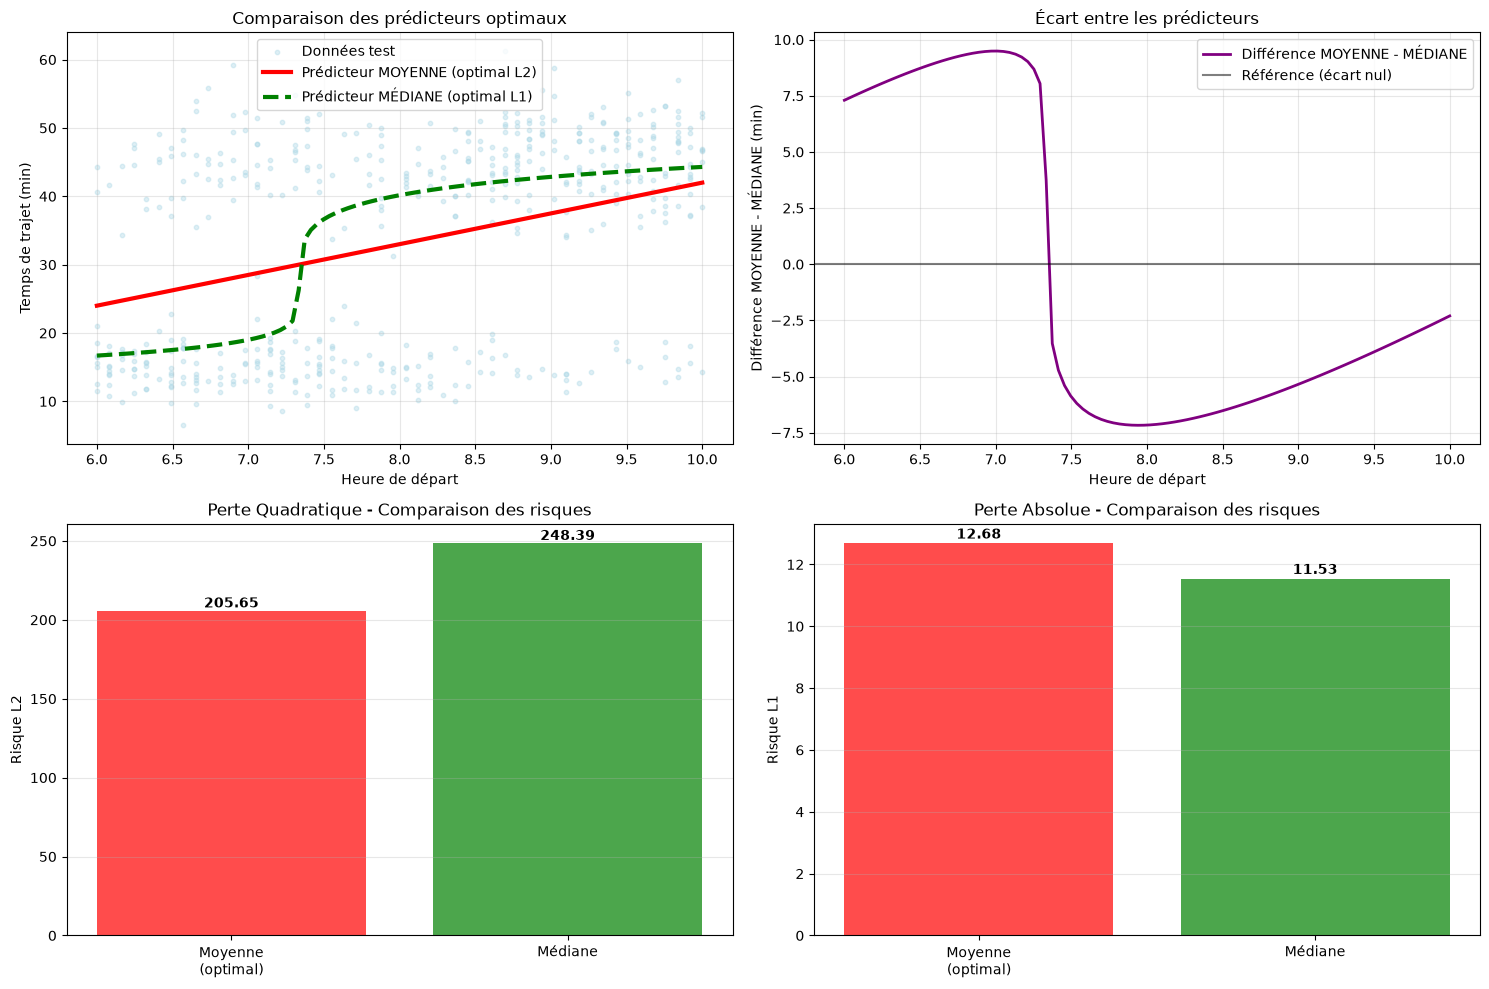

In [15]:
# Visualisation comparative
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

x_plot = np.linspace(6, 10, 100)
y_mean_plot   = theoretical_mean_predictor(x_plot)
y_median_plot = theoretical_median_predictor(x_plot)

# Sous-graphique 1: Données et prédicteurs
ax1 = axes[0, 0]
idx_sample = np.random.choice(len(X_test), min(500, len(X_test)), replace=False)
ax1.scatter(X_test[idx_sample], y_test[idx_sample], alpha=0.4, s=10,
            color='lightblue', label='Données test')
ax1.plot(x_plot, y_mean_plot,   'r-',  linewidth=3, label='Prédicteur MOYENNE (optimal L2)')
ax1.plot(x_plot, y_median_plot, 'g--', linewidth=3, label='Prédicteur MÉDIANE (optimal L1)')
ax1.set_xlabel("Heure de départ")
ax1.set_ylabel("Temps de trajet (min)")
ax1.set_title("Comparaison des prédicteurs optimaux")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Sous-graphique 2: Ecarts entre prédicteurs
ax2 = axes[0, 1]
difference = y_mean_plot - y_median_plot
ax2.plot(x_plot, difference, 'purple', linewidth=2,
         label='Différence MOYENNE - MÉDIANE')
ax2.axhline(y=0, color='black', linestyle='-', alpha=0.5,
            label='Référence (écart nul)')
ax2.set_xlabel("Heure de départ")
ax2.set_ylabel("Différence MOYENNE - MÉDIANE (min)")
ax2.set_title("Écart entre les prédicteurs")
ax2.legend()
ax2.grid(True, alpha=0.3)

# Sous-graphique 3: Comparaison des risques L2
ax3 = axes[1, 0]
predictors = ['Moyenne\n(optimal)', 'Médiane']
risks_l2 = [risk_l2_mean, risk_l2_median]
bars1 = ax3.bar(predictors, risks_l2, color=['red', 'green'], alpha=0.7)
ax3.set_ylabel('Risque L2')
ax3.set_title('Perte Quadratique - Comparaison des risques')
ax3.grid(True, alpha=0.3, axis='y')
for bar, risk in zip(bars1, risks_l2):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{risk:.2f}', ha='center', va='bottom', fontweight='bold')

# Sous-graphique 4: Comparaison des risques L1
ax4 = axes[1, 1]
risks_l1 = [risk_l1_mean, risk_l1_median]
bars2 = ax4.bar(predictors, risks_l1, color=['red', 'green'], alpha=0.7)
ax4.set_ylabel('Risque L1')
ax4.set_title('Perte Absolue - Comparaison des risques')
ax4.grid(True, alpha=0.3, axis='y')
for bar, risk in zip(bars2, risks_l1):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{risk:.2f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

In [14]:
# Validation par simulation Monte Carlo
n_simulations = 50
risks_l2_mean_sim = []
risks_l2_median_sim = []
risks_l1_mean_sim = []
risks_l1_median_sim = []

print("Validation par simulation Monte Carlo...")
for i in range(n_simulations):
    # Génération nouveau jeu de test
    X_test_sim, y_test_sim = generate_asymmetric_data(x_test_points, 100)
    
    # Prédictions
    y_pred_mean_sim = theoretical_mean_predictor(X_test_sim)
    y_pred_median_sim = theoretical_median_predictor(X_test_sim)
    
    # Calcul des risques
    risks_l2_mean_sim.append(empirical_risk_l2(y_test_sim, y_pred_mean_sim))
    risks_l2_median_sim.append(empirical_risk_l2(y_test_sim, y_pred_median_sim))
    risks_l1_mean_sim.append(empirical_risk_l1(y_test_sim, y_pred_mean_sim))
    risks_l1_median_sim.append(empirical_risk_l1(y_test_sim, y_pred_median_sim))

print(f"\n=== RÉSULTATS MONTE CARLO ({n_simulations} simulations) ===")
print("\nPERTE QUADRATIQUE (L2):")
print(f"Risque moyen - Prédicteur MOYENNE: {np.mean(risks_l2_mean_sim):.3f} ± {np.std(risks_l2_mean_sim):.3f}")
print(f"Risque moyen - Prédicteur MÉDIANE: {np.mean(risks_l2_median_sim):.3f} ± {np.std(risks_l2_median_sim):.3f}")
print(f"% cas où MOYENNE < MÉDIANE: {np.mean(np.array(risks_l2_mean_sim) < np.array(risks_l2_median_sim))*100:.1f}%")

print("\nPERTE ABSOLUE (L1):")
print(f"Risque moyen - Prédicteur MOYENNE: {np.mean(risks_l1_mean_sim):.3f} ± {np.std(risks_l1_mean_sim):.3f}")
print(f"Risque moyen - Prédicteur MÉDIANE: {np.mean(risks_l1_median_sim):.3f} ± {np.std(risks_l1_median_sim):.3f}")
print(f"% cas où MÉDIANE < MOYENNE: {np.mean(np.array(risks_l1_median_sim) < np.array(risks_l1_mean_sim))*100:.1f}%")

Validation par simulation Monte Carlo...

=== RÉSULTATS MONTE CARLO (50 simulations) ===

PERTE QUADRATIQUE (L2):
Risque moyen - Prédicteur MOYENNE: 206.573 ± 2.901
Risque moyen - Prédicteur MÉDIANE: 253.867 ± 5.074
% cas où MOYENNE < MÉDIANE: 100.0%

PERTE ABSOLUE (L1):
Risque moyen - Prédicteur MOYENNE: 12.731 ± 0.101
Risque moyen - Prédicteur MÉDIANE: 11.711 ± 0.159
% cas où MÉDIANE < MOYENNE: 100.0%


# Question 2 (M) - Cas général

Déterminer le prédicteur de Bayes pour la perte absolue dans le cas général :
Pour une valeur fixée $x \in X$, nous cherchons :

$$f^*_{l_{absolute}}(x) = \arg \min_{z \in \mathbb{R}} \mathbb{E}[|Y - z| \mid X = x] = \arg \min_{z \in \mathbb{R}} g(z)$$

avec :

$$g(z) = \int_{y \in \mathbb{R}} |y - z| p_{Y|X=x}(y) \, dy$$

## Hypothèses

- Pour chaque $x \in X$, $P(Y|X = x)$ admet une densité continue $p_{Y|X=x}$
- $Y|X = x$ admet un moment d'ordre 1 : $\mathbb{E}[|Y| \mid X = x] < \infty$
- Pour tout $z \in \mathbb{R}$, $Y - z|X = x$ admet un moment d'ordre 1

## Démonstration

### Étape 1 : Décomposition de la fonction objective

Pour un $z$ fixé, nous pouvons décomposer l'intégrale selon le signe de $(y - z)$ :

$$g(z) = \int_{-\infty}^{+\infty} |y - z| p_{Y|X=x}(y) \, dy$$

$$g(z) = \int_{-\infty}^{z} |y - z| p_{Y|X=x}(y) \, dy + \int_{z}^{+\infty} |y - z| p_{Y|X=x}(y) \, dy$$

Puisque :
- Pour $y < z$ : $|y - z| = z - y$
- Pour $y > z$ : $|y - z| = y - z$

Nous obtenons :

$$g(z) = \int_{-\infty}^{z} (z - y) p_{Y|X=x}(y) \, dy + \int_{z}^{+\infty} (y - z) p_{Y|X=x}(y) \, dy$$

### Étape 2 : Développement des intégrales

$$g(z) = z\int_{-\infty}^{z} p_{Y|X=x}(y) \, dy - \int_{-\infty}^{z} y p_{Y|X=x}(y) \, dy + \int_{z}^{+\infty} y p_{Y|X=x}(y) \, dy - z\int_{z}^{+\infty} p_{Y|X=x}(y) \, dy$$

En notant $F(z) = P(Y \leq z \mid X = x)$, nous avons :

$$g(z) = z \cdot F(z) - \int_{-\infty}^{z} y p_{Y|X=x}(y) \, dy + \int_{z}^{+\infty} y p_{Y|X=x}(y) \, dy - z \cdot (1-F(z))$$

$$g(z) = 2z \cdot F(z) - z - \int_{-\infty}^{z} y p_{Y|X=x}(y) \, dy + \int_{z}^{+\infty} y p_{Y|X=x}(y) \, dy$$

### Étape 3 : Calcul de la dérivée

Pour trouver le minimum, calculons $g'(z)$ en utilisant le théorème fondamental du calcul et la règle de Leibniz :

$$\frac{d}{dz}\left[\int_{-\infty}^{z} y p_{Y|X=x}(y) \, dy\right] = z \cdot p_{Y|X=x}(z)$$

$$\frac{d}{dz}\left[\int_{z}^{+\infty} y p_{Y|X=x}(y) \, dy\right] = -z \cdot p_{Y|X=x}(z)$$

Donc :

$$g'(z) = 2F(z) + 2z \cdot p_{Y|X=x}(z) - 1 - z \cdot p_{Y|X=x}(z) - z \cdot p_{Y|X=x}(z)$$

**Simplification** : Les termes $\pm z \cdot p_{Y|X=x}(z)$ provenant de la dérivation des bornes s'annulent.

$$\boxed{g'(z) = 2F(z) - 1 = 2P(Y \leq z \mid X = x) - 1}$$

### Étape 4 : Condition d'optimalité

Le minimum est atteint lorsque $g'(z) = 0$ :

$$2P(Y \leq z \mid X = x) - 1 = 0 \iff P(Y \leq z \mid X = x) = \frac{1}{2}$$

### Étape 5 : Vérification que c'est un minimum **global**

On étudie le **signe de $g'(z) = 2F(z) - 1$** :

- Pour $z < z^*$ : $F(z) < \dfrac{1}{2} \Rightarrow g'(z) < 0$ — $g$ est **décroissante**
- Pour $z > z^*$ : $F(z) > \dfrac{1}{2} \Rightarrow g'(z) > 0$ — $g$ est **croissante**

Ce changement de signe de $-$ à $+$ en $z^*$ garantit que $z^*$ est un **minimum global** de $g$.

> *Remarque : On pourrait aussi calculer $g''(z) = 2p_{Y|X=x}(z) \geq 0$ (densité positive), mais cela confirmerait seulement un minimum local. L'étude du signe de $g'$ est plus rigoureuse et conclut directement à un minimum global.*

## Conclusion

**Théorème** : Le prédicteur de Bayes pour la perte absolue est la **médiane conditionnelle** :

$$f^*_{l_{absolute}}(x) = \text{médiane}(Y \mid X = x)$$

c'est-à-dire la valeur $z^*$ telle que $P(Y \leq z^* \mid X = x) = \dfrac{1}{2}$.

### Interprétation géométrique

La médiane minimise la somme des écarts absolus car elle équilibre parfaitement les masses de probabilité de part et d'autre : 50% des observations sont en dessous, 50% au-dessus.

### Comparaison avec la perte quadratique

| Perte | Prédicteur optimal | Justification |
|-------|-------------------|---------------|
| **Quadratique** $l_2(y,z) = (y-z)^2$ | **Moyenne** $\mathbb{E}[Y\mid X=x]$ | Minimise la variance |
| **Absolue** $l_1(y,z) = \|y-z\|$ | **Médiane** $\text{Med}(Y\mid X=x)$ | Minimise les écarts absolus |

Cette différence est particulièrement visible pour des distributions asymétriques ou **bimodales** où moyenne $\neq$ médiane, comme dans l'exemple du temps de trajet domicile-travail.